In [3]:
# A. membangun struktur direktori HDFS
!hdfs dfs -mkdir -p /user/rosifaaulia/ecommerce/raw
!hdfs dfs -mkdir -p /user/rosifaaulia/ecommerce/processed

# menampilkan hasil sebagai bukti sudah terbentuk
!hdfs dfs -ls -R /user/rosifaaulia/ecommerce
# -ls -R digunakan untuk menampilkan isi folder hingga terlihat raw dan processednya

drwxr-xr-x   - rosifaaulia supergroup          0 2026-09-10 13:53 /user/rosifaaulia/ecommerce/processed
drwxr-xr-x   - rosifaaulia supergroup          0 2026-09-10 13:53 /user/rosifaaulia/ecommerce/raw


In [4]:
# B. mengunggah data mentah ketiga csv ke dalam direktori raw
!hdfs dfs -put transaksi_magelang.csv /user/rosifaaulia/ecommerce/raw
!hdfs dfs -put transaksi_yogyakarta.csv /user/rosifaaulia/ecommerce/raw
!hdfs dfs -put transaksi_semarang.csv /user/rosifaaulia/ecommerce/raw
# -put digunakan untuk mengupload file dari lokal ke hdfs

# menampilkan isi direktori sebagai bukti, lengkap dengan ukuran file
!hdfs dfs -ls -h /user/rosifaaulia/ecommerce/raw
# -ls -h digunakan untuk memanmpilkan isi folder dan ukuran filenya

Found 3 items
-rw-r--r--   1 rosifaaulia supergroup     12.0 K 2026-09-10 14:00 /user/rosifaaulia/ecommerce/raw/transaksi_magelang.csv
-rw-r--r--   1 rosifaaulia supergroup     11.9 K 2026-09-10 14:00 /user/rosifaaulia/ecommerce/raw/transaksi_semarang.csv
-rw-r--r--   1 rosifaaulia supergroup     12.4 K 2026-09-10 14:00 /user/rosifaaulia/ecommerce/raw/transaksi_yogyakarta.csv


In [8]:
# C. membaca kembali ketiga berkas dari HDFS
import pandas as pd
import subprocess
from io import StringIO

def baca_csv_dari_hdfs(path_hdfs):
    hasil = subprocess.run(["hdfs", "dfs", "-cat", path_hdfs], capture_output=True, text=True)
    return pd.read_csv(StringIO(hasil.stdout))

df_magelang = baca_csv_dari_hdfs("/user/rosifaaulia/ecommerce/raw/transaksi_magelang.csv")
df_yogyakarta = baca_csv_dari_hdfs("/user/rosifaaulia/ecommerce/raw/transaksi_yogyakarta.csv")
df_semarang = baca_csv_dari_hdfs("/user/rosifaaulia/ecommerce/raw/transaksi_semarang.csv")

print("Data berhasil dibaca dari HDFS: ")
print("Magelang: ", df_magelang.shape, "baris x kolom")
print("Yogyakarta: ", df_yogyakarta.shape, "baris x kolom")
print("Semaramg: ", df_semarang.shape, "baris x kolom")

# menggabungkan ketiga datanya menjadi satu DataFrame, buktikan hasil transaksi gabungan
df_gabungan = pd.concat([df_magelang, df_semarang, df_yogyakarta], ignore_index=True)
print(df_gabungan["kota"].value_counts())

Data berhasil dibaca dari HDFS: 
Magelang:  (200, 7) baris x kolom
Yogyakarta:  (200, 7) baris x kolom
Semaramg:  (200, 7) baris x kolom
kota
Magelang      200
Semarang      200
Yogyakarta    200
Name: count, dtype: int64


In [10]:
# D.Mengolah dan Download hasil ke direktori processed
# 1. Menambahkan kolom total_pendapatan (unit terjual x harga satuan)
df_gabungan["total_pendapatan"] = df_gabungan["unit_terjual"] * df_gabungan["harga_satuan"]
print(df_gabungan[["kota", "kategori", "unit_terjual", "harga_satuan", "total_pendapatan"]].head())

# 2. Buat tabel ringkasan (group by0 yang menampilkan total pendapatan per kota dan per kategori
ringkasan_kota_kategori = df_gabungan.groupby(["kota", "kategori"]) ["total_pendapatan"]. sum(). reset_index()
print(ringkasan_kota_kategori)

# 3. Menyimpan kedua hasil sebagai berkas csv baru di disk lokal lalu unggah ke processed di hdfs
df_gabungan.to_csv("data_gabungan_bersih.csv", index=False)
ringkasan_kota_kategori.to_csv("ringkasan_kota_kategori.csv", index=False)

# upload
!hdfs dfs -put -f data_gabungan_bersih.csv /user/rosifaaulia/ecommerce/processed
!hdfs dfs -put -f ringkasan_kota_kategori.csv /user/rosifaaulia/ecommerce/processed

!hdfs dfs -ls -h /user/rosifaaulia/ecommerce/processed


       kota      kategori  unit_terjual  harga_satuan  total_pendapatan
0  Magelang       Fashion             1         50000             50000
1  Magelang    Elektronik             7         25000            175000
2  Magelang    Elektronik             7         25000            175000
3  Magelang  Rumah Tangga             6         25000            150000
4  Magelang       Fashion             7        100000            700000
          kota                kategori  total_pendapatan
0     Magelang              Elektronik          18775000
1     Magelang                 Fashion          27750000
2     Magelang  Kesehatan & Kecantikan          17375000
3     Magelang       Makanan & Minuman          17525000
4     Magelang            Rumah Tangga          12200000
5     Semarang              Elektronik          21425000
6     Semarang                 Fashion          26425000
7     Semarang  Kesehatan & Kecantikan          13525000
8     Semarang       Makanan & Minuman          1975000

# E. Dokumentasi dan Refleksi
# 1. screenshoot halaman NameNode Web UI 
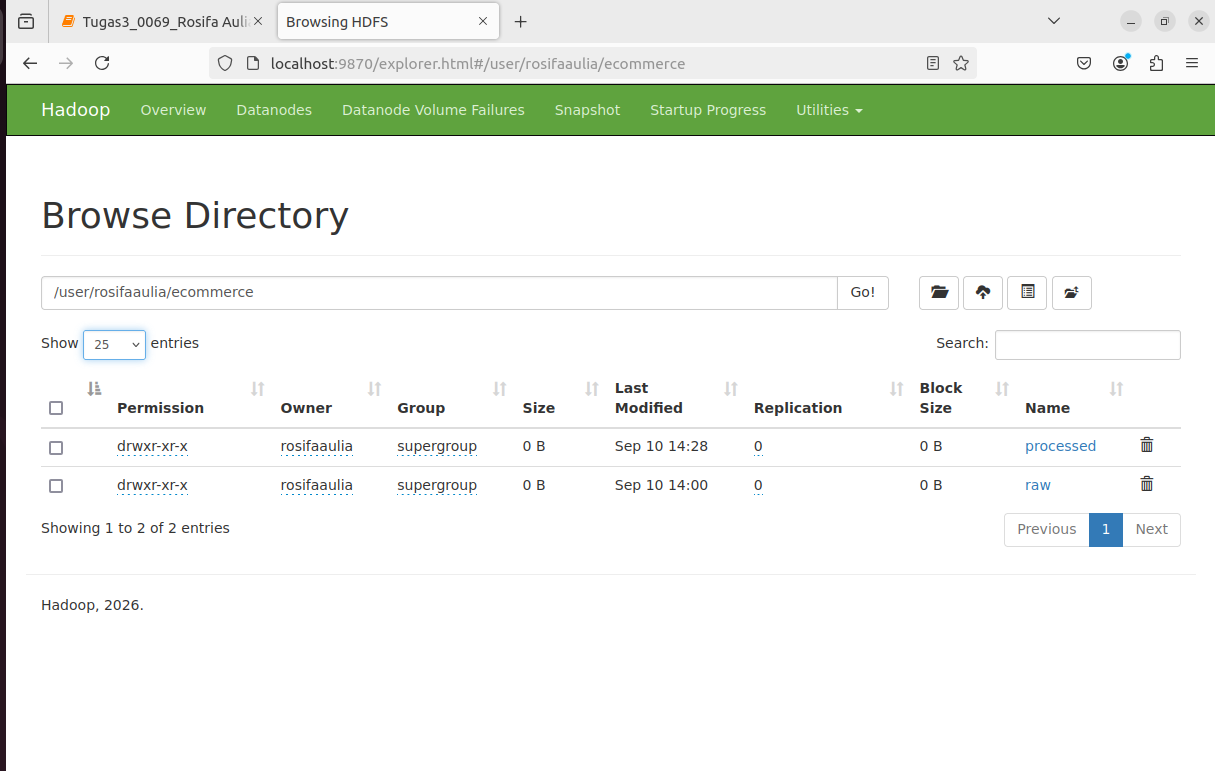

# 2. Refleksi
"menurut saya, memisahkan data raw (mentah) dan data processed (olahan) di HDFS itu penting. Pertama, karena data asli jadi tetap aman. Ketika proses pengolahan data ada yang salah, kita bisa balik lagi ke data mentahnya dan mengolah datanya dari awal tanpa takut data aslinya iktu rusak. Kedua, foldernya jadi lebih rapi, kita bisa langsung tau mana data yang belum diolah dan mana yang sudah diolah dan siap pakai, tanpa harus membuka filenya satu persatu. Ketiga, kalau semisal olahan datanya terlihat aneh, kita bisa dengan mudah menelusuri kembali ke data mentahnya untuk ngecek masalahnya dari mana. Kalau semua data dicampur menjadi satu folder, semua hal itu bisa menjadi ribet dan beresiko datanya kacau atau tertimpa."